In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [15]:
df=pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [16]:
df.shape

(27, 2)

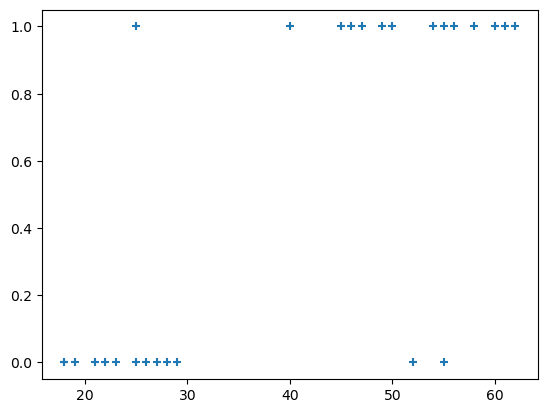

In [17]:
plt.scatter(df.age,df.bought_insurance,marker='+')

In [18]:
X=df[['age']]
Y=df[['bought_insurance']]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.8,random_state=42)

In [21]:
X_test

,age
8,62
13,29
9,61
21,26
0,22
11,28
16,25
17,58
12,27
24,50


In [25]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train.values.ravel())

LogisticRegression()

In [26]:
model.coef_


array([[0.11523991]])

In [27]:
model.intercept_

array([-5.64857389])

In [28]:
y_predicted=model.predict(X_test)

In [29]:
y_predicted

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0],
      dtype=int64)

In [32]:
df['probs']=model.predict_proba(df[['age']])[:,1]
df

,age,bought_insurance,probs
0,22,0,0.042562
1,25,0,0.059102
2,47,1,0.442185
3,52,0,0.585138
4,46,1,0.413980
5,56,1,0.691013
6,55,0,0.665883
7,60,1,0.780026
8,62,1,0.817022
9,61,1,0.799161


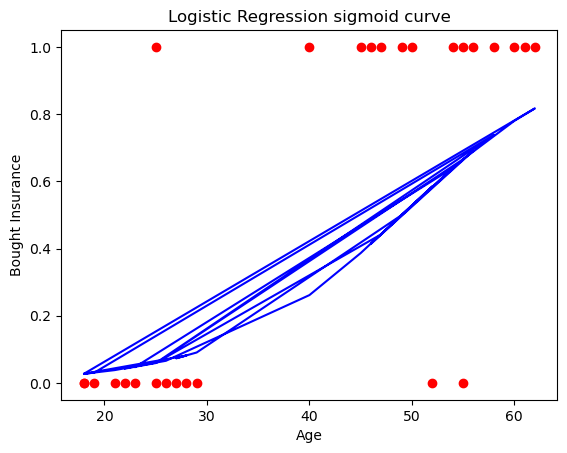

In [34]:
plt.scatter(df.age,df.bought_insurance,color="red")
plt.plot(df['age'],df['probs'],color='blue')
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Logistic Regression sigmoid curve")
plt.show()

In [44]:
import math
def sigmoid(X):
    return 1/(1+math.exp(-X))

In [45]:
def prediction_function(age):
    z=0.112*age+(-4.20)
    y=sigmoid(z)
    return y

In [46]:
age=35
prediction_function(age)

0.43045377606077095

In [47]:
age=40
prediction_function(age)

0.569546223939229

In [48]:
age=37.5
prediction_function(age)

0.5

In [49]:
age=83
prediction_function(age)

0.993916058524579

In [52]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X)
accuracy=accuracy_score(Y,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7037037037037037
